Import the libraries.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

Create the dataset.

In [16]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)
# y = 0.8x^2 + 0.9x + 2 + noise

Plot the data points.

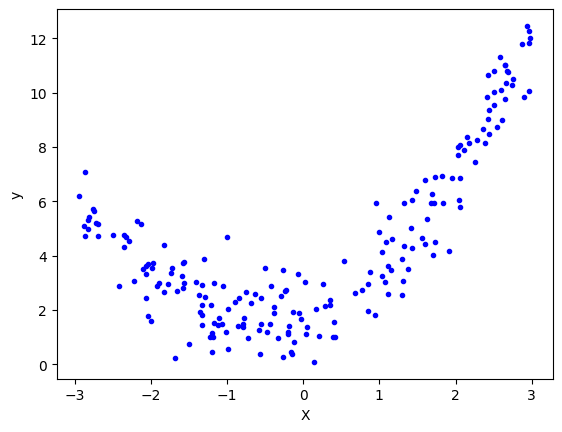

In [17]:
plt.plot(X, y, 'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

Train the model with linear regression.

In [18]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred = lr.predict(x_test)
print('R2 score for Linear Regression:', r2_score(y_test, y_pred))

R2 score for Linear Regression: 0.4354260231836088


Plot the best fit line.

Text(0.5, 1.0, 'Linear Regression')

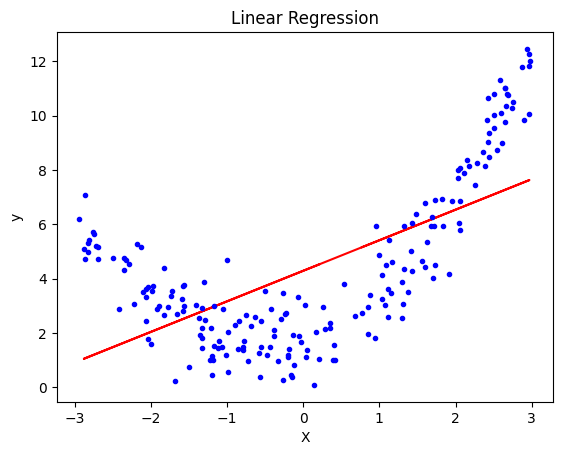

In [19]:
plt.plot(x_train, lr.predict(x_train), 'r-')
plt.plot(X, y, 'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')

Apply the polynomial features.

In [35]:
poly = PolynomialFeatures(degree=2, include_bias=True)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)
print('Original features:', x_train[0])
print('Polynomial features:', x_train_poly[0])
print('Feature names:', poly.get_feature_names_out())
print(poly.powers_)


Original features: [0.77194229]
Polynomial features: [1.         0.77194229 0.59589489]
Feature names: ['1' 'x0' 'x0^2']
[[0]
 [1]
 [2]]


Train the new features with linear regression.

In [21]:
lr_poly = LinearRegression()
lr_poly.fit(x_train_poly, y_train)
y_poly_pred = lr_poly.predict(x_test_poly)
print('R2 score for Polynomial Regression:', r2_score(y_test, y_poly_pred))

R2 score for Polynomial Regression: 0.9081696555131801


Print the parameters.

In [22]:
print('Coefficients for Linear Regression:', lr.coef_)
print('Intercept for Linear Regression:', lr.intercept_)
print('Coefficients for Polynomial Regression:', lr_poly.coef_)
print('Intercept for Polynomial Regression:', lr_poly.intercept_)

Coefficients for Linear Regression: [[1.12478357]]
Intercept for Linear Regression: [4.28918649]
Coefficients for Polynomial Regression: [[0.         0.8992673  0.83474791]]
Intercept for Polynomial Regression: [1.76618739]


Create a new dataset.

In [23]:
x_new = np.linspace(-3, 3, 200).reshape(200, 1)
x_new_poly = poly.transform(x_new)
y_new_poly = lr_poly.predict(x_new_poly)

Plot the datapoint and best fit line.

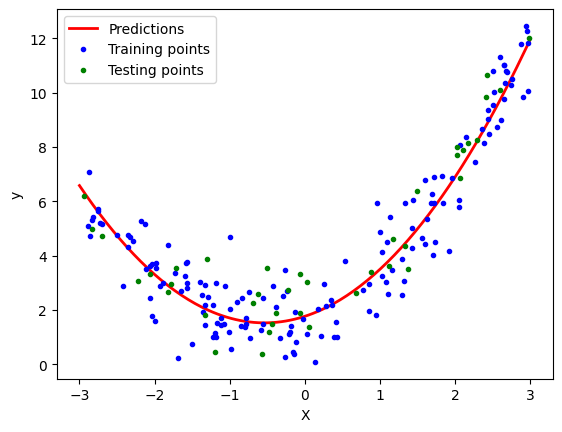

In [24]:
plt.plot(x_new, y_new_poly, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

Pipeline to create a flow of data and plot the data points along with the curve.

In [32]:
def PolynomialRegressor(degree):
    x_new = np.linspace(-3, 3, 200).reshape(200, 1)
    x_new_poly = poly.transform(x_new)

    polynomial_regression = Pipeline([
            ("poly_features", PolynomialFeatures(degree=degree, include_bias=True)),
            ("std_scaler", StandardScaler()),
            ("lin_reg", LinearRegression()),
        ])
    polynomial_regression.fit(x_train, y_train)
    y_newbig = polynomial_regression.predict(x_new)
    
    plt.plot(x_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(x_train, y_train, "b.", linewidth=3)
    plt.plot(x_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

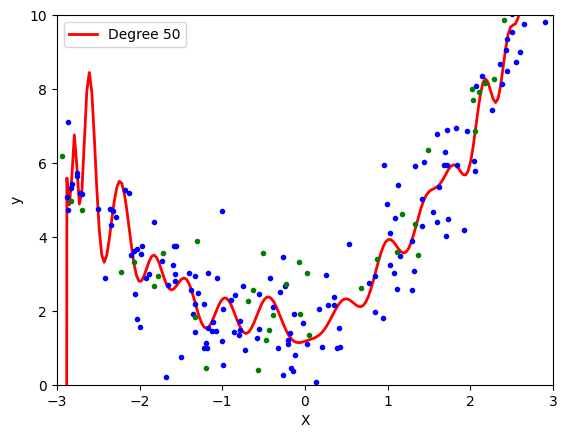

In [33]:
PolynomialRegressor(50)

Apply the Gradient descent on degree 2 polynomial.

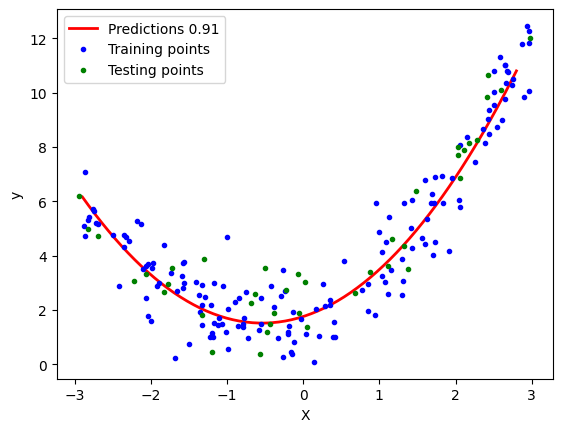

In [ ]:
poly = PolynomialFeatures(degree=2)
scaler = StandardScaler()

X_train_trans = poly.fit_transform(x_train)
X_test_trans = poly.transform(x_test)

X_train_scaled = scaler.fit_transform(X_train_trans)
X_test_scaled = scaler.transform(X_test_trans)

sgd = SGDRegressor(max_iter=1000, tol=1e-3)
sgd.fit(X_train_scaled, y_train.ravel())

X_new = np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_scaled = scaler.transform(X_new_poly)

y_new = sgd.predict(X_new_scaled)
y_pred = sgd.predict(X_test_scaled)


plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

Find the r2 score

In [38]:
r2_score(y_test, y_pred)


0.907307104105734

Create a new 3D data.

In [39]:
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2 + noise

3D plot the 3D data.

In [40]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

Train the model on linear regression and find the predicted values.

In [44]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z) # Reshape to (100, 2) for fitting

x_input = np.linspace(x.min(), x.max(), 10) # 10 points between min and max of x
y_input = np.linspace(y.min(), y.max(), 10) # 10 points between min and max of y
xGrid, yGrid = np.meshgrid(x_input,y_input) # Create a grid of x and y values for prediction

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T # Stack the grid into a (100, 2) array for prediction

z_final = lr.predict(final).reshape(10,10) # Reshape the predicted z values back into a 10x10 grid for plotting

Apply the polynomial regrssion of degreee 5 on the data and find related info.

In [43]:
x_multi = np.array([x,y]).reshape(100,2)
x_multi.shape
poly = PolynomialFeatures(degree=5)
x_multi_trans = poly.fit_transform(x_multi)

print("Input", poly.n_features_in_)
print("Output", poly.n_output_features_)
print("Powers\n", poly.powers_)

Input 2
Output 21
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]
 [3 0]
 [2 1]
 [1 2]
 [0 3]
 [4 0]
 [3 1]
 [2 2]
 [1 3]
 [0 4]
 [5 0]
 [4 1]
 [3 2]
 [2 3]
 [1 4]
 [0 5]]


Train the model and

In [45]:
x_multi_trans.shape
lr = LinearRegression()
lr.fit(x_multi_trans,z)
LinearRegression()
X_test_multi = poly.transform(final)

Plot the predicted value (obtain curve) in 3D.

In [47]:
import plotly.graph_objects as go

z_final = lr.predict(x_multi_trans).reshape(10,10)
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()